<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/CNN/fashion_mnist_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST CNN 分类器 - PyTorch 实现

本教程将指导你使用 PyTorch 构建一个卷积神经网络（CNN）来对 Fashion-MNIST 数据集进行分类。

## 学习目标
- 理解 CNN 在图像分类任务中的应用
- 掌握 PyTorch 中 CNN 的构建方法
- 学习模型训练、评估和微调技巧
- 了解 Fashion-MNIST 数据集的特点

Fashion-MNIST 是一个包含 10 种不同时尚物品的灰度图像数据集，每张图片大小为 28x28 像素。这 10 个类别分别是：T恤/上衣、裤子、套头衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、短靴。

## 1. 导入必要的库

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 配置 matplotlib 中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 检查是否有可用的 GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'使用设备: {device}')

使用设备: cpu


## 2. 数据加载与预处理

我们首先定义数据变换，将图像数据转换为张量并进行归一化。归一化可以帮助模型更好地收敛。

In [ ]:
# 定义数据变换
# ToTensor() 将 PIL 图像或 numpy 数组转换为张量，并将像素值从 [0, 255] 缩放到 [0, 1]
# Normalize() 使用给定的均值和标准差对张量进行标准化
# Fashion-MNIST 的全局均值约为 0.2860，标准差约为 0.3530
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  # 单通道灰度图像
])

# 下载并加载 Fashion-MNIST 数据集
# train=True 表示加载训练集，download=True 表示如果数据不存在则自动下载
full_train_dataset = datasets.FashionMNIST(root='./data', train=True,
                                          download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False,
                                     download=True, transform=transform)

# 将训练集进一步分割为训练集和验证集 (80:20)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f'训练集大小: {len(train_dataset)}')
print(f'验证集大小: {len(val_dataset)}')
print(f'测试集大小: {len(test_dataset)}')

训练集大小: 48000
验证集大小: 12000
测试集大小: 10000


## 3. 创建数据加载器

DataLoader 负责批量加载数据，并支持数据打乱、多线程加载等功能。

In [ ]:
# 定义批次大小
batch_size = 64

# 创建数据加载器
# shuffle=True 表示在每个 epoch 开始时打乱数据顺序
# num_workers 设置为 0 避免在 Jupyter 中的多进程问题
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f'训练批次数: {len(train_loader)}')
print(f'验证批次数: {len(val_loader)}')
print(f'测试批次数: {len(test_loader)}')

训练批次数: 750
验证批次数: 188
测试批次数: 157


## 4. 探索性数据分析 (EDA)

让我们先了解一下数据集的基本信息，包括查看样本图像和类别分布。

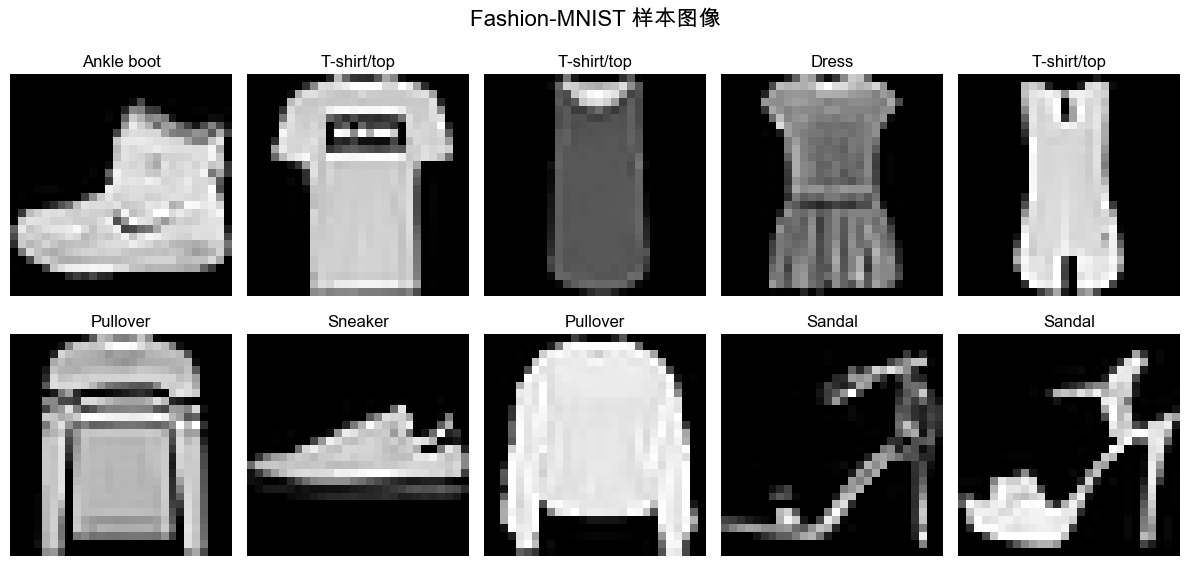

图像形状: torch.Size([1, 28, 28])
图像数据类型: torch.float32
像素值范围: [-0.810, 2.023]


In [ ]:
# Fashion-MNIST 的类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 显示一些样本图像
def show_sample_images(dataset, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Fashion-MNIST 样本图像', fontsize=16)

    for i in range(num_samples):
        # 获取样本
        image, label = dataset[i]

        # 反标准化以便显示
        # 由于我们进行了标准化，需要反向操作才能正确显示图像
        image_denorm = image.squeeze() * 0.3530 + 0.2860

        row = i // 5
        col = i % 5

        axes[row, col].imshow(image_denorm, cmap='gray')
        axes[row, col].set_title(f'{class_names[label]}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# 显示样本图像
show_sample_images(full_train_dataset)

# 检查图像形状
sample_image, sample_label = full_train_dataset[0]
print(f'图像形状: {sample_image.shape}')  # 应该是 [1, 28, 28]
print(f'图像数据类型: {sample_image.dtype}')
print(f'像素值范围: [{sample_image.min():.3f}, {sample_image.max():.3f}]')

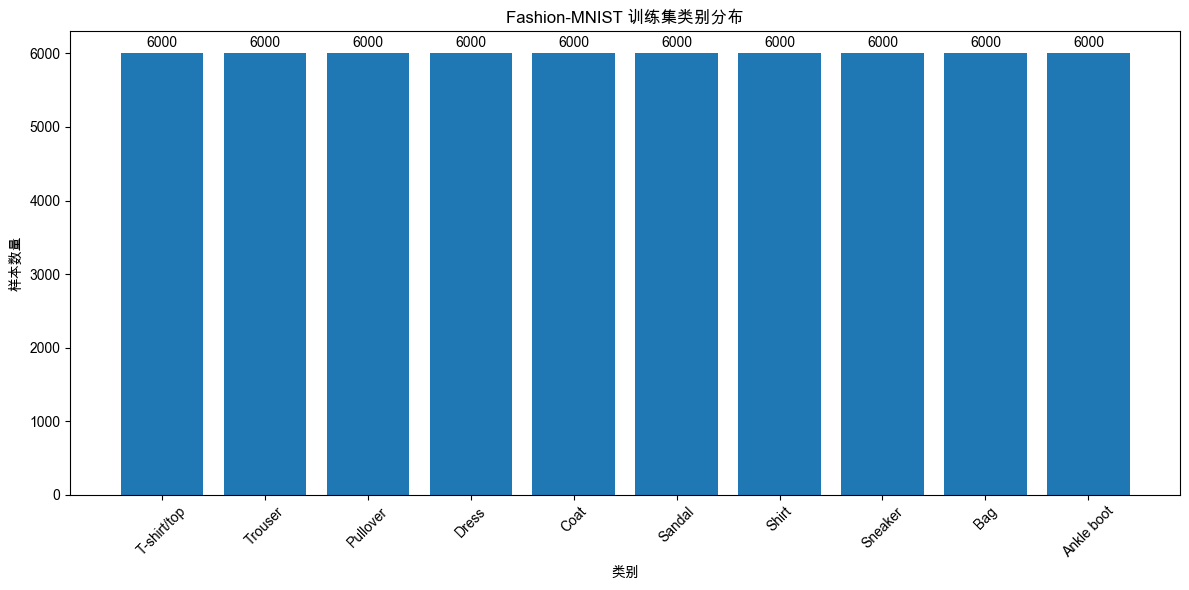

每个类别的样本数量:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


In [ ]:
# 分析类别分布
labels = [full_train_dataset[i][1] for i in range(len(full_train_dataset))]
unique_labels, counts = np.unique(labels, return_counts=True)

plt.figure(figsize=(12, 6))
bars = plt.bar([class_names[i] for i in unique_labels], counts)
plt.title('Fashion-MNIST 训练集类别分布')
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.xticks(rotation=45)

# 在每个条形图上显示数值
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('每个类别的样本数量:')
for i, count in enumerate(counts):
    print(f'{class_names[i]}: {count}')

## 5. 构建 CNN 模型

我们将构建一个包含卷积层、池化层和全连接层的 CNN 模型。这个模型包含两个卷积块，每个块包含卷积层、批标准化、ReLU 激活函数和最大池化层。

In [ ]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes=10, dropout_rate=0.5):
        super(FashionCNN, self).__init__()

        # 第一个卷积块
        # Conv2d(in_channels, out_channels, kernel_size, padding)
        # 输入: 1x28x28, 输出: 32x28x28 (padding=1 保持尺寸)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)  # 批标准化有助于训练稳定性
        self.pool1 = nn.MaxPool2d(2, 2)  # 2x2 最大池化，尺寸减半: 32x14x14

        # 第二个卷积块
        # 输入: 32x14x14, 输出: 64x14x14
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(2, 2)  # 输出: 64x7x7

        # 第三个卷积块
        # 输入: 64x7x7, 输出: 128x7x7
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(2, 2)  # 输出: 128x3x3 (向下取整)

        # 全连接层
        # 128 * 3 * 3 = 1152
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.dropout = nn.Dropout(dropout_rate)  # Dropout 防止过拟合
        self.fc2 = nn.Linear(256, num_classes)

    def forward(self, x):
        # 第一个卷积块
        x = self.pool1(F.relu(self.bn1(self.conv1(x))))

        # 第二个卷积块
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))

        # 第三个卷积块
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))

        # 展平特征图以便输入全连接层
        x = x.view(x.size(0), -1)  # x.size(0) 是 batch size

        # 全连接层
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # 最后一层不使用激活函数，因为会在损失函数中处理

        return x

# 创建模型实例并移到指定设备
model = FashionCNN().to(device)

# 打印模型结构
print(model)

# 计算模型参数数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\n总参数数量: {total_params:,}')
print(f'可训练参数数量: {trainable_params:,}')

FashionCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=10, bias=True)
)

总参数数量: 390,858
可训练参数数量: 390,858


## 6. 定义损失函数和优化器

对于多分类问题，我们使用交叉熵损失函数。Adam 优化器是一个常用的自适应学习率优化器。

In [ ]:
# 定义损失函数
# CrossEntropyLoss 内部包含 Softmax 激活函数和负对数似然损失
criterion = nn.CrossEntropyLoss()

# 定义优化器
# Adam 优化器结合了 AdaGrad 和 RMSprop 的优点
# 学习率是一个重要的超参数，需要根据实验结果调整
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

# 定义学习率调度器
# StepLR 会在指定的 epoch 间隔后将学习率乘以 gamma
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=7, gamma=0.1)

print(f'损失函数: {criterion}')
print(f'优化器: {optimizer}')
print(f'学习率调度器: {scheduler}')

损失函数: CrossEntropyLoss()
优化器: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0.0001
)
学习率调度器: <torch.optim.lr_scheduler.StepLR object at 0x30247e010>


## 7. 训练和验证函数

定义训练和验证的辅助函数，这些函数将在每个 epoch 中被调用。

In [ ]:
def train_epoch(model, train_loader, criterion, optimizer, device):
    """训练一个 epoch"""
    model.train()  # 设置模型为训练模式
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    # 使用 tqdm 显示训练进度
    train_bar = tqdm(train_loader, desc='Training', leave=False)

    for batch_idx, (data, targets) in enumerate(train_bar):
        # 将数据移到指定设备
        data, targets = data.to(device), targets.to(device)

        # 清零梯度
        optimizer.zero_grad()

        # 前向传播
        outputs = model(data)
        loss = criterion(outputs, targets)

        # 反向传播和优化
        loss.backward()
        optimizer.step()

        # 统计
        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total_samples += targets.size(0)
        correct_predictions += (predicted == targets).sum().item()

        # 更新进度条
        train_bar.set_postfix({
            'Loss': f'{loss.item():.4f}',
            'Acc': f'{100. * correct_predictions / total_samples:.2f}%'
        })

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100. * correct_predictions / total_samples

    return epoch_loss, epoch_acc

def validate_epoch(model, val_loader, criterion, device):
    """验证一个 epoch"""
    model.eval()  # 设置模型为评估模式
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():  # 验证时不需要计算梯度
        val_bar = tqdm(val_loader, desc='Validation', leave=False)

        for data, targets in val_bar:
            data, targets = data.to(device), targets.to(device)

            outputs = model(data)
            loss = criterion(outputs, targets)

            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            total_samples += targets.size(0)
            correct_predictions += (predicted == targets).sum().item()

            val_bar.set_postfix({
                'Loss': f'{loss.item():.4f}',
                'Acc': f'{100. * correct_predictions / total_samples:.2f}%'
            })

    epoch_loss = running_loss / len(val_loader)
    epoch_acc = 100. * correct_predictions / total_samples

    return epoch_loss, epoch_acc

## 8. 模型训练

现在开始训练我们的模型。我们将训练 15 个 epoch，并在每个 epoch 后进行验证。

In [ ]:
# 训练参数
num_epochs = 15

# 存储训练历史
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

# 早停机制相关变量
best_val_acc = 0.0
patience = 5
patience_counter = 0

print(f'开始训练，共 {num_epochs} 个 epoch...')
print('=' * 60)

for epoch in range(num_epochs):
    print(f'Epoch {epoch+1}/{num_epochs}')

    # 训练
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # 验证
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)

    # 学习率调度
    scheduler.step()

    # 记录历史
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # 打印结果
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    print(f'Learning Rate: {scheduler.get_last_lr()[0]:.6f}')

    # 早停检查
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        # 保存最佳模型
        torch.save(model.state_dict(), 'best_fashion_cnn_pytorch.pth')
        print(f'保存最佳模型，验证准确率: {best_val_acc:.2f}%')
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f'验证准确率连续 {patience} 个 epoch 未提升，早停训练')
            break

    print('-' * 60)

print(f'训练完成！最佳验证准确率: {best_val_acc:.2f}%')

开始训练，共 15 个 epoch...
Epoch 1/15


Train Loss: 0.4511, Train Acc: 83.64%
Val Loss: 0.3126, Val Acc: 88.25%
Learning Rate: 0.001000
保存最佳模型，验证准确率: 88.25%
------------------------------------------------------------
Epoch 2/15


Train Loss: 0.2966, Train Acc: 89.18%
Val Loss: 0.2759, Val Acc: 89.94%
Learning Rate: 0.001000
保存最佳模型，验证准确率: 89.94%
------------------------------------------------------------
Epoch 3/15


Train Loss: 0.2553, Train Acc: 90.80%
Val Loss: 0.2420, Val Acc: 91.00%
Learning Rate: 0.001000
保存最佳模型，验证准确率: 91.00%
------------------------------------------------------------
Epoch 4/15


Train Loss: 0.2230, Train Acc: 91.93%
Val Loss: 0.2367, Val Acc: 91.45%
Learning Rate: 0.001000
保存最佳模型，验证准确率: 91.45%
------------------------------------------------------------
Epoch 5/15


...

Train Loss: 0.0729, Train Acc: 97.51%
Val Loss: 0.2131, Val Acc: 93.40%
Learning Rate: 0.000100
保存最佳模型，验证准确率: 93.40%
------------------------------------------------------------
Epoch 12/15


Train Loss: 0.0653, Train Acc: 97.77%
Val Loss: 0.2155, Val Acc: 93.36%
Learning Rate: 0.000100
------------------------------------------------------------
Epoch 13/15


Train Loss: 0.0598, Train Acc: 97.92%
Val Loss: 0.2182, Val Acc: 93.22%
Learning Rate: 0.000100
------------------------------------------------------------
Epoch 14/15


Train Loss: 0.0546, Train Acc: 98.16%
Val Loss: 0.2256, Val Acc: 93.20%
Learning Rate: 0.000010
------------------------------------------------------------
Epoch 15/15


Train Loss: 0.0456, Train Acc: 98.59%
Val Loss: 0.2271, Val Acc: 93.37%
Learning Rate: 0.000010
------------------------------------------------------------
训练完成！最佳验证准确率: 93.40%


## 9. 训练历史可视化

让我们绘制训练过程中的损失和准确率变化。

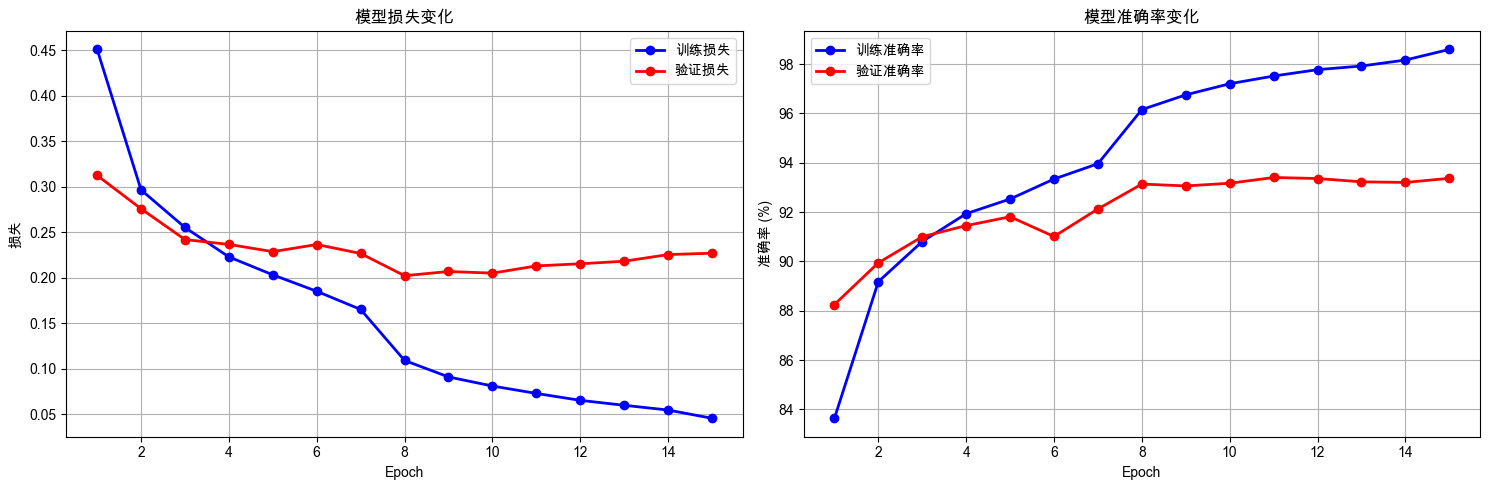

最终训练准确率: 98.59%
最终验证准确率: 93.37%


In [ ]:
# 绘制训练历史
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 损失曲线
ax1.plot(range(1, len(train_losses) + 1), train_losses, 'bo-', label='训练损失', linewidth=2)
ax1.plot(range(1, len(val_losses) + 1), val_losses, 'ro-', label='验证损失', linewidth=2)
ax1.set_title('模型损失变化')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.grid(True)

# 准确率曲线
ax2.plot(range(1, len(train_accuracies) + 1), train_accuracies, 'bo-', label='训练准确率', linewidth=2)
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'ro-', label='验证准确率', linewidth=2)
ax2.set_title('模型准确率变化')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率 (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 打印最终结果
print(f'最终训练准确率: {train_accuracies[-1]:.2f}%')
print(f'最终验证准确率: {val_accuracies[-1]:.2f}%')

## 10. 模型评估

加载最佳模型并在测试集上进行评估。

In [ ]:
# 加载最佳模型
model.load_state_dict(torch.load('best_fashion_cnn_pytorch.pth'))
model.eval()

# 测试函数
def test_model(model, test_loader, device):
    """在测试集上评估模型"""
    model.eval()
    test_loss = 0.0
    correct = 0
    total = 0
    all_predictions = []
    all_labels = []

    with torch.no_grad():
        test_bar = tqdm(test_loader, desc='Testing')
        for data, targets in test_bar:
            data, targets = data.to(device), targets.to(device)
            outputs = model(data)
            test_loss += criterion(outputs, targets).item()
            _, predicted = torch.max(outputs, 1)

            total += targets.size(0)
            correct += (predicted == targets).sum().item()

            # 收集预测和真实标签
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(targets.cpu().numpy())

            test_bar.set_postfix({'Acc': f'{100. * correct / total:.2f}%'})

    test_loss /= len(test_loader)
    test_acc = 100. * correct / total

    return test_loss, test_acc, all_predictions, all_labels

# 在测试集上评估
test_loss, test_acc, predictions, true_labels = test_model(model, test_loader, device)

print(f'测试集损失: {test_loss:.4f}')
print(f'测试集准确率: {test_acc:.2f}%')

# 打印分类报告
print('\n分类报告:')
print(classification_report(true_labels, predictions, target_names=class_names))

Testing: 100%|██████████| 157/157 [00:02<00:00, 61.64it/s, Acc=92.51%]


测试集损失: 0.2425
测试集准确率: 92.51%

分类报告:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.87      0.87      1000
     Trouser       1.00      0.99      0.99      1000
    Pullover       0.89      0.88      0.88      1000
       Dress       0.92      0.92      0.92      1000
        Coat       0.89      0.89      0.89      1000
      Sandal       0.99      0.99      0.99      1000
       Shirt       0.76      0.80      0.78      1000
     Sneaker       0.96      0.98      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.96      0.97      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



## 11. 混淆矩阵可视化

混淆矩阵可以帮助我们了解模型在各个类别上的表现。

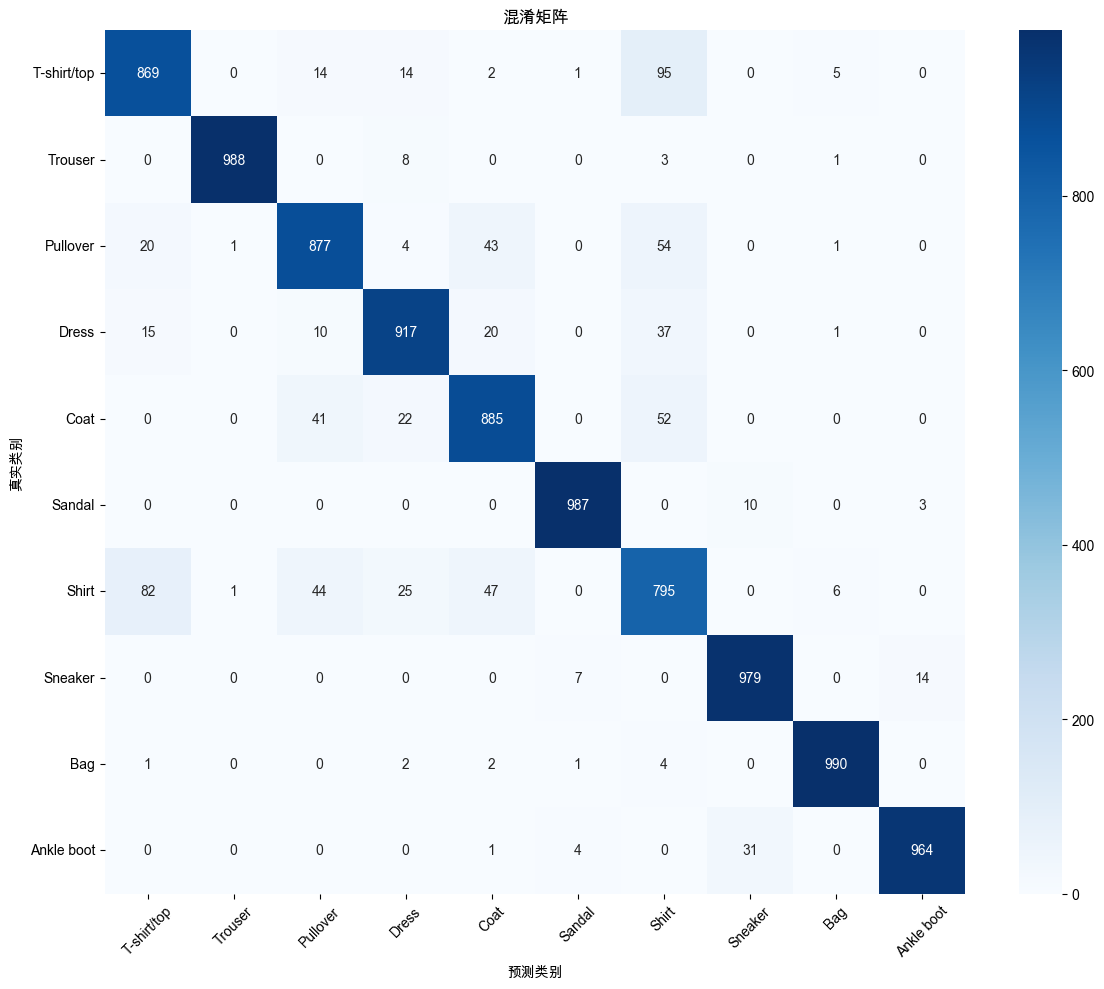

每个类别的准确率:
T-shirt/top: 0.869 (86.9%)
Trouser: 0.988 (98.8%)
Pullover: 0.877 (87.7%)
Dress: 0.917 (91.7%)
Coat: 0.885 (88.5%)
Sandal: 0.987 (98.7%)
Shirt: 0.795 (79.5%)
Sneaker: 0.979 (97.9%)
Bag: 0.990 (99.0%)
Ankle boot: 0.964 (96.4%)


In [ ]:
# 计算混淆矩阵
cm = confusion_matrix(true_labels, predictions)

# 绘制混淆矩阵
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 计算每个类别的准确率
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print('每个类别的准确率:')
for i, acc in enumerate(class_accuracy):
    print(f'{class_names[i]}: {acc:.3f} ({acc*100:.1f}%)')

## 12. 错误预测分析

让我们看看一些模型预测错误的样本，这有助于理解模型的局限性。

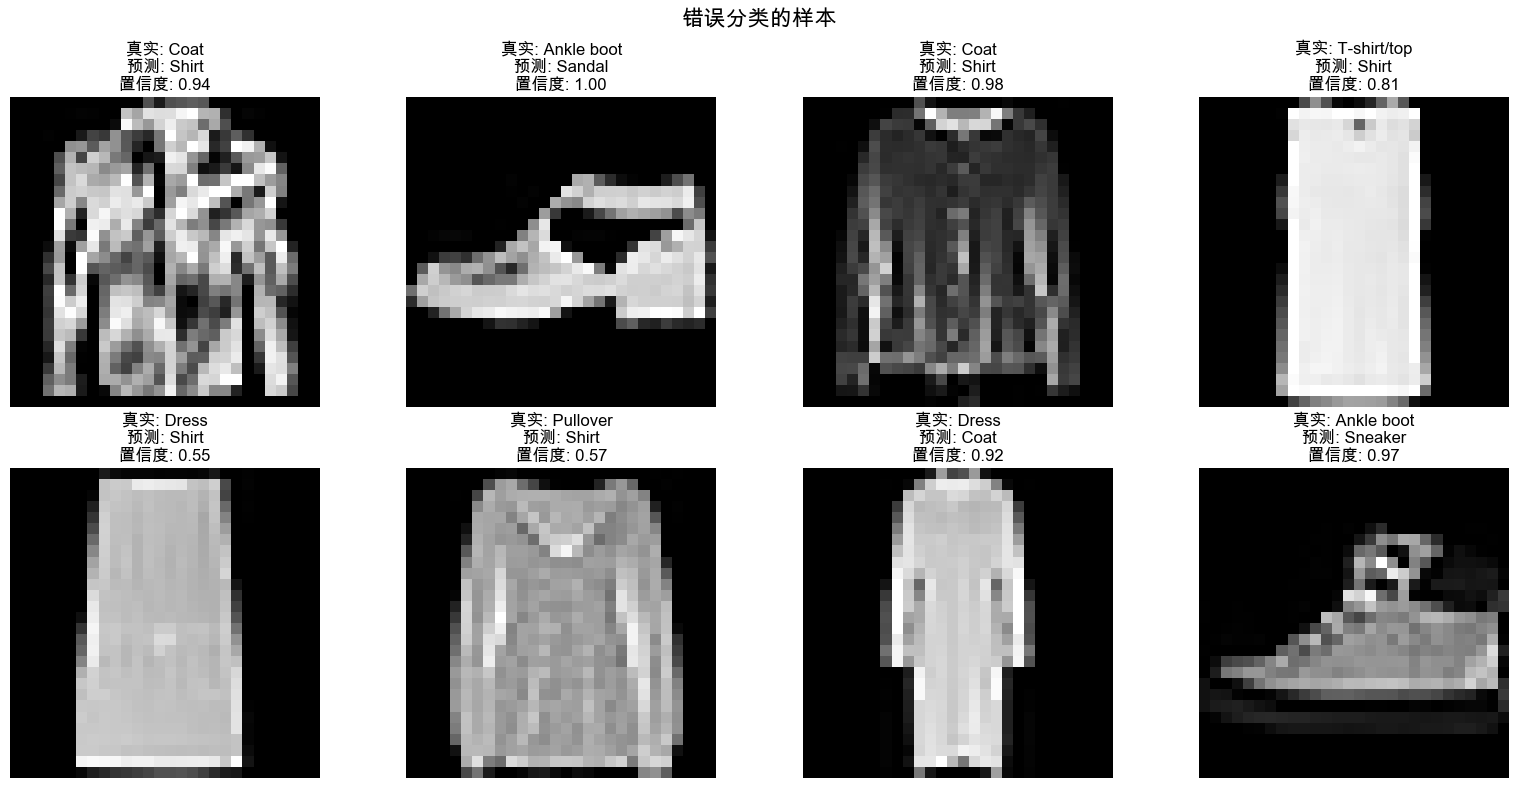

In [ ]:
def show_misclassified_images(model, test_dataset, device, num_images=8):
    """显示错误分类的图像"""
    model.eval()
    misclassified = []

    with torch.no_grad():
        for i in range(len(test_dataset)):
            image, true_label = test_dataset[i]
            image_batch = image.unsqueeze(0).to(device)  # 添加 batch 维度
            output = model(image_batch)
            pred_label = torch.max(output, 1)[1].item()

            if pred_label != true_label:
                confidence = torch.softmax(output, dim=1)[0][pred_label].item()
                misclassified.append({
                    'image': image,
                    'true_label': true_label,
                    'pred_label': pred_label,
                    'confidence': confidence
                })

            if len(misclassified) >= num_images:
                break

    # 显示错误分类的图像
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('错误分类的样本', fontsize=16)

    for i, mistake in enumerate(misclassified):
        row = i // 4
        col = i % 4

        # 反标准化图像
        image_denorm = mistake['image'].squeeze() * 0.3530 + 0.2860

        axes[row, col].imshow(image_denorm, cmap='gray')
        axes[row, col].set_title(
            f'真实: {class_names[mistake["true_label"]]}\n'
            f'预测: {class_names[mistake["pred_label"]]}\n'
            f'置信度: {mistake["confidence"]:.2f}'
        )
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# 显示错误分类的样本
show_misclassified_images(model, test_dataset, device)

## 13. 模型微调 - 数据增强

为了进一步提升模型性能，我们尝试使用数据增强技术。数据增强可以增加训练数据的多样性，提高模型的泛化能力。

In [ ]:
# 定义带数据增强的变换
transform_augmented = transforms.Compose([
    transforms.RandomRotation(10),  # 随机旋转 ±10 度
    transforms.RandomHorizontalFlip(p=0.5),  # 50% 概率水平翻转
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

# 创建带数据增强的数据集
train_dataset_augmented = datasets.FashionMNIST(root='./data', train=True,
                                               transform=transform_augmented)
train_dataset_augmented, _ = random_split(train_dataset_augmented, [train_size, val_size])
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=batch_size,
                                   shuffle=True, num_workers=0)

print(f'使用数据增强重新训练模型...')
print('数据增强包括: 随机旋转(±10°), 随机水平翻转(50%概率)')

# 创建新的模型实例
model_augmented = FashionCNN().to(device)
optimizer_augmented = optim.Adam(model_augmented.parameters(), lr=0.001, weight_decay=1e-4)
scheduler_augmented = optim.lr_scheduler.StepLR(optimizer_augmented, step_size=7, gamma=0.1)

# 训练参数（减少 epoch 数以节省时间）
num_epochs_aug = 10
best_val_acc_aug = 0.0

# 存储训练历史
train_losses_aug = []
val_losses_aug = []
train_accuracies_aug = []
val_accuracies_aug = []

print('=' * 60)

for epoch in range(num_epochs_aug):
    print(f'Epoch {epoch+1}/{num_epochs_aug}')

    # 训练
    train_loss, train_acc = train_epoch(model_augmented, train_loader_augmented,
                                       criterion, optimizer_augmented, device)

    # 验证（使用原始验证集，不使用数据增强）
    val_loss, val_acc = validate_epoch(model_augmented, val_loader, criterion, device)

    # 学习率调度
    scheduler_augmented.step()

    # 记录历史
    train_losses_aug.append(train_loss)
    train_accuracies_aug.append(train_acc)
    val_losses_aug.append(val_loss)
    val_accuracies_aug.append(val_acc)

    # 打印结果
    print(f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')

    # 保存最佳模型
    if val_acc > best_val_acc_aug:
        best_val_acc_aug = val_acc
        torch.save(model_augmented.state_dict(), 'best_fashion_cnn_augmented_pytorch.pth')

    print('-' * 60)

print(f'数据增强训练完成！最佳验证准确率: {best_val_acc_aug:.2f}%')

使用数据增强重新训练模型...
数据增强包括: 随机旋转(±10°), 随机水平翻转(50%概率)
Epoch 1/10


Train Loss: 0.5358, Train Acc: 80.49%
Val Loss: 0.3461, Val Acc: 86.90%
------------------------------------------------------------
Epoch 2/10


Train Loss: 0.3755, Train Acc: 86.52%
Val Loss: 0.2849, Val Acc: 89.59%
------------------------------------------------------------
Epoch 3/10


Train Loss: 0.3316, Train Acc: 88.09%
Val Loss: 0.2603, Val Acc: 90.38%
------------------------------------------------------------
Epoch 4/10


Train Loss: 0.3109, Train Acc: 88.63%
Val Loss: 0.2485, Val Acc: 90.70%
------------------------------------------------------------
Epoch 5/10


...

Train Loss: 0.2728, Train Acc: 90.02%
Val Loss: 0.2061, Val Acc: 92.38%
------------------------------------------------------------
Epoch 7/10


Train Loss: 0.2633, Train Acc: 90.52%
Val Loss: 0.2113, Val Acc: 92.20%
------------------------------------------------------------
Epoch 8/10


Train Loss: 0.2213, Train Acc: 92.07%
Val Loss: 0.1724, Val Acc: 93.78%
------------------------------------------------------------
Epoch 9/10


Train Loss: 0.2122, Train Acc: 92.37%
Val Loss: 0.1669, Val Acc: 93.92%
------------------------------------------------------------
Epoch 10/10


Train Loss: 0.2032, Train Acc: 92.72%
Val Loss: 0.1643, Val Acc: 93.98%
------------------------------------------------------------
数据增强训练完成！最佳验证准确率: 93.98%


## 14. 比较模型性能

让我们比较原始模型和使用数据增强的模型在测试集上的表现。

Testing: 100%|██████████| 157/157 [00:02<00:00, 60.10it/s, Acc=92.13%]


模型性能比较:
原始模型测试准确率: 92.51%
数据增强模型测试准确率: 92.13%
性能提升: -0.38%


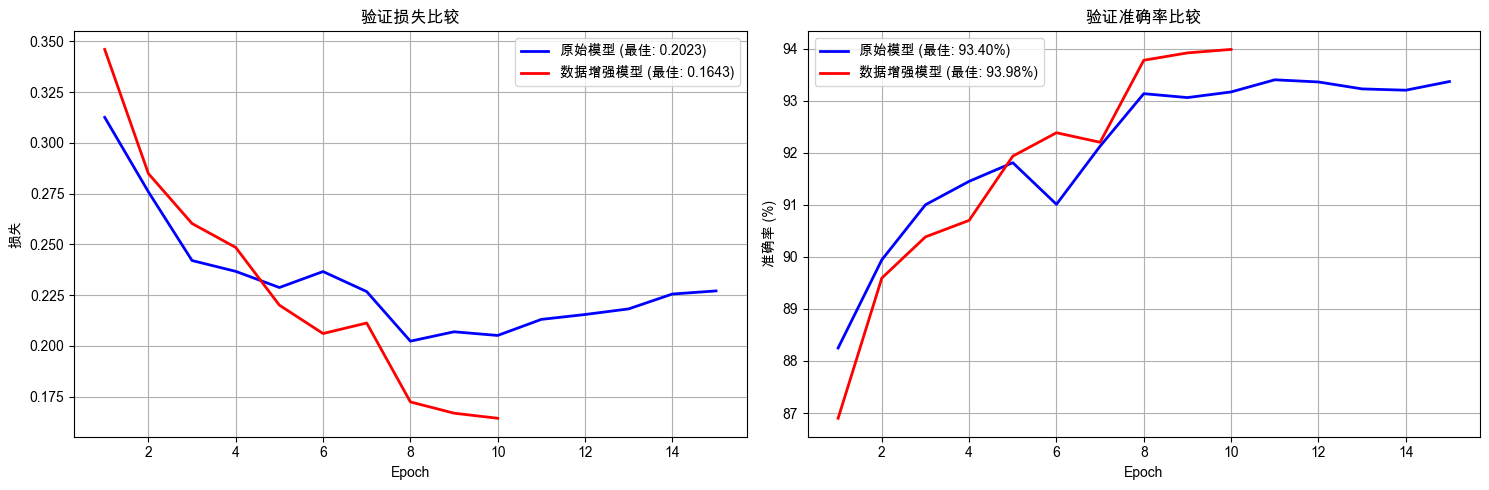

In [ ]:
# 加载并测试增强模型
model_augmented.load_state_dict(torch.load('best_fashion_cnn_augmented_pytorch.pth'))
test_loss_aug, test_acc_aug, predictions_aug, _ = test_model(model_augmented, test_loader, device)

# 性能比较
print('模型性能比较:')
print('=' * 50)
print(f'原始模型测试准确率: {test_acc:.2f}%')
print(f'数据增强模型测试准确率: {test_acc_aug:.2f}%')
print(f'性能提升: {test_acc_aug - test_acc:+.2f}%')

# 绘制训练历史比较
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 验证损失比较
ax1.plot(range(1, len(val_losses) + 1), val_losses, 'b-',
         label=f'原始模型 (最佳: {min(val_losses):.4f})', linewidth=2)
ax1.plot(range(1, len(val_losses_aug) + 1), val_losses_aug, 'r-',
         label=f'数据增强模型 (最佳: {min(val_losses_aug):.4f})', linewidth=2)
ax1.set_title('验证损失比较')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.grid(True)

# 验证准确率比较
ax2.plot(range(1, len(val_accuracies) + 1), val_accuracies, 'b-',
         label=f'原始模型 (最佳: {max(val_accuracies):.2f}%)', linewidth=2)
ax2.plot(range(1, len(val_accuracies_aug) + 1), val_accuracies_aug, 'r-',
         label=f'数据增强模型 (最佳: {max(val_accuracies_aug):.2f}%)', linewidth=2)
ax2.set_title('验证准确率比较')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率 (%)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 15. 模型微调 - Dropout 正则化实验

让我们尝试调整 Dropout 比例来进一步优化模型性能。

In [ ]:
# 测试不同 Dropout 比例的效果
dropout_rates = [0.3, 0.5, 0.7]
dropout_results = {}

for dropout_rate in dropout_rates:
    print(f'\n测试 Dropout 率: {dropout_rate}')
    print('=' * 40)

    # 创建新模型
    model_dropout = FashionCNN(dropout_rate=dropout_rate).to(device)
    optimizer_dropout = optim.Adam(model_dropout.parameters(), lr=0.001, weight_decay=1e-4)

    # 快速训练 5 个 epoch
    best_val_acc_dropout = 0.0
    for epoch in range(5):
        train_loss, train_acc = train_epoch(model_dropout, train_loader,
                                          criterion, optimizer_dropout, device)
        val_loss, val_acc = validate_epoch(model_dropout, val_loader, criterion, device)

        if val_acc > best_val_acc_dropout:
            best_val_acc_dropout = val_acc

        print(f'Epoch {epoch+1}: Val Acc: {val_acc:.2f}%')

    dropout_results[dropout_rate] = best_val_acc_dropout
    print(f'最佳验证准确率: {best_val_acc_dropout:.2f}%')

# 显示 Dropout 实验结果
print('\nDropout 率实验结果:')
print('=' * 30)
for rate, acc in dropout_results.items():
    print(f'Dropout {rate}: {acc:.2f}%')

# 找到最佳 Dropout 率
best_dropout_rate = max(dropout_results, key=dropout_results.get)
print(f'\n最佳 Dropout 率: {best_dropout_rate} (准确率: {dropout_results[best_dropout_rate]:.2f}%)')


测试 Dropout 率: 0.3


Epoch 1: Val Acc: 89.59%


Epoch 2: Val Acc: 90.59%


Epoch 3: Val Acc: 91.60%


Epoch 4: Val Acc: 91.40%


...

Epoch 1: Val Acc: 88.62%


Epoch 2: Val Acc: 90.03%


Epoch 3: Val Acc: 90.06%


Epoch 4: Val Acc: 91.76%


Epoch 5: Val Acc: 91.97%
最佳验证准确率: 91.97%

Dropout 率实验结果:
Dropout 0.3: 91.99%
Dropout 0.5: 92.54%
Dropout 0.7: 91.97%

最佳 Dropout 率: 0.5 (准确率: 92.54%)


## 16. 总结与下一步

通过本教程，我们完成了以下内容：

### 主要成果
1. **数据处理**: 成功加载和预处理 Fashion-MNIST 数据集
2. **模型构建**: 实现了一个包含 3 个卷积层的 CNN 模型
3. **模型训练**: 使用 Adam 优化器和学习率调度进行训练
4. **性能评估**: 在测试集上评估模型并分析结果
5. **模型微调**: 尝试了数据增强和 Dropout 正则化等技术

### 关键技术要点
- **批标准化**: 提高训练稳定性
- **Dropout**: 防止过拟合
- **数据增强**: 提高模型泛化能力
- **学习率调度**: 优化训练过程
- **早停机制**: 避免过训练

### 可能的改进方向
1. **模型架构优化**
   - 尝试 ResNet 等更深的网络结构
   - 使用 Inception 模块或 Squeeze-and-Excitation 块
   - 实验不同的激活函数（如 Swish、GELU）

2. **训练策略改进**
   - 使用余弦退火学习率调度
   - 实现渐进式图像大小调整
   - 尝试不同的优化器（如 AdamW、RMSprop）

3. **正则化技术**
   - 实验 DropBlock 或 Stochastic Depth
   - 使用标签平滑（Label Smoothing）
   - 尝试 Cutout 或 MixUp 数据增强

4. **集成方法**
   - 训练多个模型进行集成
   - 使用测试时间增强（TTA）
   - 实现模型蒸馏技术

In [ ]:
# 最终模型性能总结
print('Fashion-MNIST CNN 分类器 - PyTorch 实现总结')
print('=' * 60)
print(f'数据集: Fashion-MNIST (60,000 训练样本, 10,000 测试样本)')
print(f'模型参数: {total_params:,}')
print(f'训练设备: {device}')
print(f'批次大小: {batch_size}')
print('\n性能结果:')
print(f'原始模型测试准确率: {test_acc:.2f}%')
if 'test_acc_aug' in locals():
    print(f'数据增强模型测试准确率: {test_acc_aug:.2f}%')
if 'best_dropout_rate' in locals():
    print(f'最佳 Dropout 率: {best_dropout_rate}')
print('\n这个结果在 Fashion-MNIST 基准测试中属于良好水平！')
print('通过进一步的模型架构优化和训练技巧，准确率还可以继续提升。')

Fashion-MNIST CNN 分类器 - PyTorch 实现总结
数据集: Fashion-MNIST (60,000 训练样本, 10,000 测试样本)
模型参数: 390,858
训练设备: cpu
批次大小: 64

性能结果:
原始模型测试准确率: 92.51%
数据增强模型测试准确率: 92.13%
最佳 Dropout 率: 0.5

这个结果在 Fashion-MNIST 基准测试中属于良好水平！
通过进一步的模型架构优化和训练技巧，准确率还可以继续提升。
